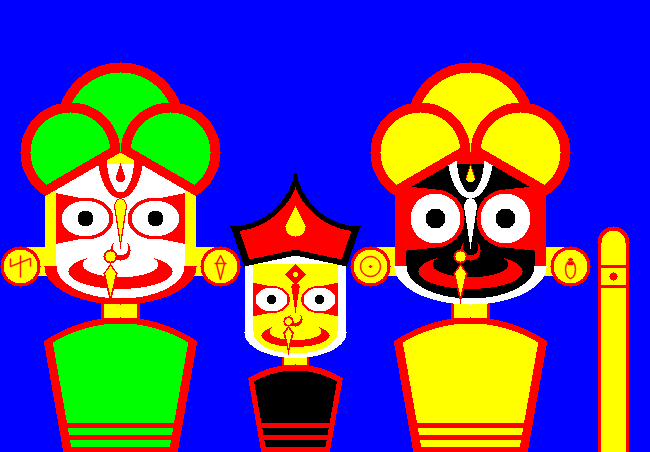

In [2]:
import numpy as np
import cv2
from numba import njit
from google.colab.patches import cv2_imshow

# Width and height constraints from the C code
width, height = 650, 452

@njit
def render_pixels(img):
    # Mapping the Turbo C BGI Palette colors to standard BGR arrays
    # 0: Black, 1: Blue, 2: Green, 4: Red, 12: Light Red, 14: Yellow, 15: White
    c0  = np.array([0, 0, 0], dtype=np.uint8)
    c1  = np.array([255, 0, 0], dtype=np.uint8)
    c2  = np.array([0, 255, 0], dtype=np.uint8)
    c4  = np.array([0, 0, 255], dtype=np.uint8)
    c12 = np.array([0, 0, 255], dtype=np.uint8)
    c14 = np.array([0, 255, 255], dtype=np.uint8)
    c15 = np.array([255, 255, 255], dtype=np.uint8)

    # EXACT same nested loops as your C file
    for i in range(0, 650):
        for j in range(0, 452):
            a = i - 120
            b = i - 295
            c = i - 470
            y = abs(452 - j) - 226

            # Conditional tree exactly matching the sequential if-else logic of LORD.c
            if (a+10)**2 + (y+30)**2 <= 7**2 or ((10*abs(a+10) + 7*y + 259 <= 0) and (30*abs(a+10) - 7*y - 539 <= 0)):
                if (a+10)**2 + (y+30)**2 <= 5**2 or ((10*abs(a+10) + 7*y + 275 <= 0) and (30*abs(a+10) - 7*y - 489 <= 0)):
                    img[j, i] = c14
                else:
                    img[j, i] = c4

            elif (b+7)**2 + (y+95)**2 <= 5**2 or ((7*abs(b+7) + 5*y + 495 <= 0) and (21*abs(b+7) - 5*y - 640 <= 0)):
                if (b+7)**2 + (y+95)**2 <= 3.5**2 or ((7*abs(b+7) + 5*y + 510 <= 0) and (21*abs(b+7) - 5*y - 605 <= 0)):
                    img[j, i] = c14
                else:
                    img[j, i] = c4

            elif (c+10)**2 + (y+30)**2 <= 7**2 or ((10*abs(c+10) + 7*y + 259 <= 0) and (30*abs(c+10) - 7*y - 539 <= 0)):
                if (c+10)**2 + (y+30)**2 <= 5**2 or ((10*abs(c+10) + 7*y + 275 <= 0) and (30*abs(c+10) - 7*y - 489 <= 0)):
                    img[j, i] = c14
                else:
                    img[j, i] = c4

            elif (abs(a)-50)**2 + (y-74)**2 <= 50**2 and 11*abs(a) + 19*y - 1406 >= 0:
                if (abs(a)-50)**2 + (y-74)**2 <= 40**2 and 11*abs(a) + 19*y - 1406 >= 200:
                    img[j, i] = c2
                else:
                    img[j, i] = c4

            elif a**2 + (y-100)**2 <= 64**2 and y >= 74:
                if a**2 + (y-100)**2 <= 54**2 and y >= 74:
                    img[j, i] = c2
                else:
                    img[j, i] = c4

            elif 11*abs(b) + 51*y + 1479 >= 0 and 20*abs(b) - 7*y - 1300 <= 0 and ((abs(b)-65)**2 + (y-65)**2 >= 65**2 and y < 55):
                if (2*abs(b) + y <= 20 and y >= 0) or (b**2 + y**2 <= 10**2 and y < 0):
                    img[j, i] = c14
                elif 11*abs(b) + 51*y + 1479 >= 300 and 20*abs(b) - 7*y - 1300 <= -150 and ((abs(b)-65)**2 + (y-65)**2 >= 70**2 and y < 55):
                    img[j, i] = c4
                else:
                    img[j, i] = c0

            elif (abs(c)-50)**2 + (y-74)**2 <= 50**2 and 11*abs(c) + 19*y - 1406 >= 0:
                if (abs(c)-50)**2 + (y-74)**2 <= 40**2 and 11*abs(c) + 19*y - 1406 >= 200:
                    img[j, i] = c14
                else:
                    img[j, i] = c4

            elif c**2 + (y-100)**2 <= 64**2 and y >= 74:
                if c**2 + (y-100)**2 <= 54**2 and y >= 74:
                    img[j, i] = c14
                else:
                    img[j, i] = c4

            elif a**2 + 4*(y+40)**2 <= 76**2 or (abs(a) < 76 and abs(y-17) < 57):
                if 4*a**2 + (y-74)**2 <= 46**2 and 8*a**2 + (y-74)**2 >= 40**2:
                    img[j, i] = c4
                elif a**2 + (y-49)**2 < 25 or (3*abs(a) + y < 64 and y > 49):
                    if (a**2 + (y-49)**2 < 16 and y < 49) or (3*abs(a) + y < 61 and y >= 49):
                        img[j, i] = c12
                    else:
                        img[j, i] = c4
                elif (a**2 + (y-23)**2 <= 28 and y >= 23) or (45*abs(a) - 7*y - 154 <= 0 and y < 23):
                    if (a**2 + (y-23)**2 >= 20 and y >= 23) or (45*abs(a) - 7*y - 100 >= 0 and y < 23):
                        img[j, i] = c4
                    else:
                        img[j, i] = c14
                elif (abs(a) > 64 or y > 62) and y > -40:
                    img[j, i] = c14
                elif a**2 + 4*(y+40)**2 >= 64**2 and y <= -40:
                    img[j, i] = c4
                elif a**2 + (y+24)**2 <= 10**2 and a**2 + (y+21)**2 >= 8**2:
                    img[j, i] = c4
                elif (abs(a)-35)**2 + (y-8)**2 < 8**2:
                    img[j, i] = c0
                elif 9*(abs(a)-35)**2 + 16*(y-8)**2 < 71**2:
                    img[j, i] = c15
                elif 9*(abs(a)-35)**2 + 16*(y-8)**2 < 84**2 or (abs(y-8) <= 0.2*(abs(a)-63) + 25 and abs(a) > 35):
                    img[j, i] = c4
                elif a**2 + 9*(y+45)**2 <= 52**2 and a**2 + 9*(y+38)**2 >= 38**2:
                    img[j, i] = c4
                else:
                    img[j, i] = c15

            elif b**2 + 4*(y+106)**2 <= 51**2 or (abs(b) < 51 and abs(y+67.5) < 38.5):
                if (abs(b) > 42 or y > -38) and y > -106:
                    img[j, i] = c15
                elif b**2 + 4*(y+106)**2 >= 42**2 and y <= -106:
                    img[j, i] = c15
                elif abs(b) + abs(y+48) <= 10:
                    if b**2 + (y+48)**2 <= 5:
                        img[j, i] = c14
                    elif abs(b) + abs(y+48) <= 8:
                        img[j, i] = c12
                    else:
                        img[j, i] = c4
                elif (b**2 + (y+61)**2 <= 18 and y >= -61) or (45*abs(b) - 7*y - 607 <= 0 and y < -61):
                    if (b**2 + (y+61)**2 >= 10 and y >= -61) or (45*abs(b) - 7*y - 550 >= 0 and y < -61):
                        img[j, i] = c4
                    else:
                        img[j, i] = c12
                elif b**2 + (y+93)**2 <= 7**2 and b**2 + (y+91)**2 >= 5.2**2:
                    img[j, i] = c4
                elif (abs(b)-24)**2 + (y+73)**2 < 5**2:
                    img[j, i] = c0
                elif 9*(abs(b)-24)**2 + 16*(y+73)**2 < 48**2:
                    img[j, i] = c15
                elif 9*(abs(b)-24)**2 + 16*(y+73)**2 <= 55**2 or (abs(y+73) <= 0.2*(abs(b)-44) + 17 and abs(b) > 24):
                    img[j, i] = c4
                elif b**2 + 9*(y+109)**2 <= 34**2 and b**2 + 9*(y+105)**2 >= 26**2:
                    img[j, i] = c4
                else:
                    img[j, i] = c14

            elif c**2 + 4*(y+40)**2 <= 76**2 or (abs(c) < 76 and abs(y-17) < 57):
                if 4*c**2 + (y-74)**2 <= 46**2 and 8*c**2 + (y-74)**2 >= 40**2:
                    img[j, i] = c15
                elif c**2 + (y-49)**2 < 25 or (3*abs(c) + y < 64 and y > 49):
                    if (c**2 + (y-49)**2 < 16 and y < 49) or (3*abs(c) + y < 61 and j >= 49):
                        img[j, i] = c14
                    else:
                        img[j, i] = c4
                elif (c**2 + (y-23)**2 <= 28 and y >= 23) or (45*abs(c) - 7*y - 154 <= 0 and y < 23):
                    img[j, i] = c15
                elif (abs(c) > 64 or y > 62) and y > -40:
                    img[j, i] = c12
                elif c**2 + 4*(y+40)**2 >= 64**2 and y <= -40:
                    img[j, i] = c15
                elif c**2 + (y+24)**2 <= 10**2 and c**2 + (y+21)**2 >= 8**2:
                    img[j, i] = c4
                elif (abs(c)-35)**2 + (y-8)**2 < 10**2:
                    img[j, i] = c0
                elif (abs(c)-35)**2 + (y-8)**2 < 25**2:
                    img[j, i] = c15
                elif (abs(c)-35)**2 + (y-8)**2 <= 29**2 or (abs(y-8) <= 0.1*(abs(c)-64) + 32 and abs(c) > 35):
                    img[j, i] = c4
                elif c**2 + 9*(y+45)**2 <= 52**2 and c**2 + 9*(y+38)**2 >= 38**2:
                    img[j, i] = c4
                else:
                    img[j, i] = c0

            elif a**2 + (y+226)**2 <= 135**2 and y >= 5.67*abs(a) - 550:
                if (a**2 + (y+226)**2 >= 129**2 or y <= 5.67*abs(a) - 500 or y < -220 or (y > -214 and y < -208) or (y > -202 and y < -196)):
                    img[j, i] = c4
                else:
                    img[j, i] = c2

            elif b**2 + (y+226)**2 <= 88**2 and y >= 5.67*abs(b) - 420:
                if (b**2 + (y+226)**2 >= 82**2 or y <= 5.67*abs(b) - 390 or y < -220 or (y > -214 and y < -208) or (y > -202 and y < -196)):
                    img[j, i] = c4
                else:
                    img[j, i] = c0

            elif c**2 + (y+226)**2 <= 135**2 and y >= 5.67*abs(c) - 550:
                if (c**2 + (y+226)**2 >= 129**2 or y <= 5.67*abs(c) - 500 or y < -220 or (y > -214 and y < -208) or (y > -202 and y < -196)):
                    img[j, i] = c4
                else:
                    img[j, i] = c14

            elif abs(a) < 20 and y < -40:
                if abs(a) > 16:
                    img[j, i] = c4
                else:
                    img[j, i] = c14

            elif abs(b) < 14 and y < -106:
                if abs(b) > 11:
                    img[j, i] = c4
                else:
                    img[j, i] = c14

            elif abs(c) < 20 and y < -40:
                if abs(c) > 16:
                    img[j, i] = c4
                else:
                    img[j, i] = c14

            elif (abs(a)-100)**2 + (y+40)**2 <= 400 or (abs(y+35) < 15 and abs(abs(a)-88) < 15):
                if (abs(a)-100)**2 + (y+40)**2 >= 289 and (abs(a)-100)**2 + (y+40)**2 <= 400:
                    img[j, i] = c4
                else:
                    img[j, i] = c14

            elif (abs(c)-100)**2 + (y+40)**2 <= 400 or (abs(y+35) < 15 and abs(abs(c)-88) < 15):
                if (abs(c)-100)**2 + (y+40)**2 >= 289 and (abs(c)-100)**2 + (y+40)**2 <= 400:
                    img[j, i] = c4
                else:
                    img[j, i] = c14

            elif (abs(c-143) < 16 and y < -16) or (c-143)**2 + (y+16)**2 <= 16**2:
                if (abs(c-143) > 12 and y < -16) or ((c-143)**2 + (y+16)**2 >= 12**2 and y >= -16):
                    img[j, i] = c4
                elif abs(y+40) < 2 or abs(y+60) < 2 or (c-143)**2 + (y+50)**2 <= 16:
                    img[j, i] = c4
                else:
                    img[j, i] = c14
            else:
                img[j, i] = c1  # Default Background Blue

# --- Run Execution Environment ---
img_canvas = np.zeros((height, width, 3), dtype=np.uint8)

# Triggers compiled pixel matrix loop calculation
render_pixels(img_canvas)

# Vector layer modifications from the bottom block of your C code
color_red = (0, 0, 255)
cv2.line(img_canvas, (20, 255), (20, 277), color_red, 1, cv2.LINE_AA)
cv2.line(img_canvas, (10, 266), (30, 258), color_red, 1, cv2.LINE_AA)
cv2.line(img_canvas, (30, 258), (30, 266), color_red, 1, cv2.LINE_AA)
cv2.line(img_canvas, (10, 258), (10, 266), color_red, 1, cv2.LINE_AA)

cv2.line(img_canvas, (220, 255), (224, 263), color_red, 1, cv2.LINE_AA)
cv2.line(img_canvas, (224, 263), (220, 279), color_red, 1, cv2.LINE_AA)
cv2.line(img_canvas, (220, 279), (216, 263), color_red, 1, cv2.LINE_AA)
cv2.line(img_canvas, (216, 263), (220, 255), color_red, 1, cv2.LINE_AA)
cv2.line(img_canvas, (214, 263), (226, 263), color_red, 1, cv2.LINE_AA)

cv2.circle(img_canvas, (370, 266), 1, color_red, -1, cv2.LINE_AA)
cv2.circle(img_canvas, (370, 266), 10, color_red, 1, cv2.LINE_AA)

cv2.ellipse(img_canvas, (570, 269), (5, 9), 0, 0, 360, color_red, 1, cv2.LINE_AA)
cv2.ellipse(img_canvas, (570, 263), (3, 1), 0, 0, 360, color_red, -1, cv2.LINE_AA)
cv2.ellipse(img_canvas, (570, 259), (2, 1), 0, 0, 360, color_red, -1, cv2.LINE_AA)

# Display Canvas Output Frame
cv2_imshow(img_canvas)